In [1]:
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch
import random
import importlib
import ipywidgets as widgets
import numpy as np
import torch
from IPython.display import display, clear_output
from ipycanvas import Canvas, hold_canvas
import gltensor

data_path = r"..\data\NeRF\tiny_nerf_data.npz"
data = np.load(data_path)

print(data)


NpzFile '..\\data\\NeRF\\tiny_nerf_data.npz' with keys: images, poses, focal


## 输入
- 注意：NeRF里面都是以像素为单位
- pose：相机位置姿态矩阵：相机空间->世界空间(C2W)
- focal：焦距（像素单位）
- 成像高度和宽度就是image的宽高

In [2]:
images = data["images"]  # 图像
poses = data["poses"]  # 相机位姿
focal = data["focal"]  # 相机焦距
images.shape, poses.shape, focal

((106, 100, 100, 3), (106, 4, 4), array(138.8888789))

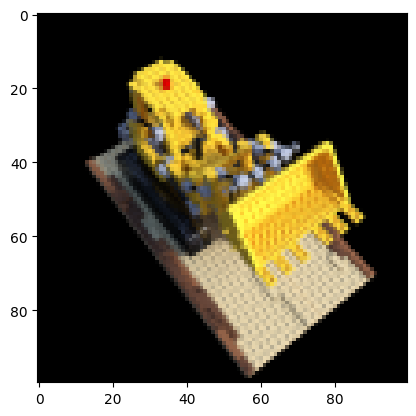

In [3]:
plt.imshow(images[3])  # 图片

## 数据处理

# 样本生成

In [4]:
near = 2.0
far = 6.0
num_images = images.shape[0]
height = images.shape[1]
width = images.shape[2]
channels = images.shape[3]
nbatchimages = 8
nimagerays = 8
nraypoints = 128
loc_encode_L = 10
dir_encode_L = 4
innerdim = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device: ", device)

images = torch.tensor(images, device=device)
poses = torch.tensor(poses, device=device)

# pixel => camera position
p2c = torch.tensor(
    [
        [1, 0, 0],  #
        [0, -1, 0],  #
        [-width / 2.0, height / 2, -focal],
    ],
    dtype=torch.float,
    device=device,
)


def tensor_random(a, b, size, dtype) -> torch.Tensor:
    return a + (b - a) * torch.rand(size=size, dtype=dtype, device=device)


def gen_colrow_rand(width, height, nimagerays):
    ws = torch.randint(0, width, (nimagerays, 1), dtype=torch.int, device=device)
    hs = torch.randint(0, height, (nimagerays, 1), dtype=torch.int, device=device)
    return ws, hs


def gen_colrow_full(width, height):
    ys, xs = torch.meshgrid(
        torch.arange(height, device=device), torch.arange(width, device=device), indexing="ij"
    )
    coords = torch.stack([xs, ys], dim=-1).reshape(-1, 2)
    ws, hs = torch.split(coords, [1, 1], dim=-1)
    return ws, hs


def gen_points(train=True, pose=torch.empty(size=(3,))):

    ray_o_list = []
    ray_d_list = []
    ray_target_list = []

    if train:
        image_indices = range(num_images)
        image_indices = random.choices(image_indices, k=nbatchimages)
    else:
        image_indices = [0]

    for i in image_indices:
        if train:
            ws, hs = gen_colrow_rand(width, height, nimagerays)
            rgb = images[i, hs, ws].squeeze(dim=1)
            ray_target_list.append(rgb)
        else:
            ws, hs = gen_colrow_full(width, height)

        if train:
            pose = poses[i]

        ones = torch.ones(size=(ws.size(0), 1), dtype=torch.float, device=device)
        ray_o = torch.tensor([0, 0, 0, 1], dtype=torch.float, device=device)
        ray_o = ray_o @ pose.T
        ray_o = ray_o[:3]
        ray_o = ray_o.reshape(-1, 3).expand(ws.size(0), 3)
        pix = torch.concat([ws, hs, ones], dim=1)
        cpos = pix @ p2c
        cpos = torch.concat([cpos, ones], dim=1)
        wpos = cpos @ pose.T
        wpos = wpos[:, :3]
        ray_d = F.normalize(input=wpos - ray_o, dim=1)
        ray_o_list.append(ray_o)
        ray_d_list.append(ray_d)

    ray_o = torch.concat(ray_o_list, dim=0)
    ray_d = torch.concat(ray_d_list, dim=0)
    points_o = ray_o.unsqueeze(dim=1).expand(-1, nraypoints, -1)
    points_d = ray_d.unsqueeze(dim=1).expand(-1, nraypoints, -1)
    # zval = torch.sort(tensor_random(near, far, (nraypoints,), torch.float))[0]
    zval = torch.linspace(near, far, nraypoints, dtype=torch.float, device=device)
    points_t = zval.unsqueeze(dim=0).unsqueeze(dim=2).expand(points_o.size(0), -1, -1)
    if train:
        dz = (far - near) / (nraypoints - 1)
        points_t = points_t + (torch.rand_like(points_t) - 0.5) * dz
        points_t = points_t.clamp(near, far)
        points_t, _ = torch.sort(points_t, dim=1)

    deltas = points_t[:, 1:, 0] - points_t[:, :-1, 0]
    deltas = torch.cat([deltas, torch.full_like(deltas[:, :1], 1e8)], dim=1)
    deltas = deltas[..., None]
    point_locs = points_o + points_d * points_t
    point_dirs = points_d

    if train:
        ray_target = torch.concat(ray_target_list, dim=0)
    else:
        ray_target = None

    return point_locs, point_dirs, deltas, ray_target


def location_encode(
    point_locs: torch.Tensor, point_dirs: torch.Tensor
) -> tuple[torch.Tensor, torch.Tensor]:

    loc_list = [point_locs]
    dir_list = [point_dirs]

    for k in range(loc_encode_L):
        a: torch.Tensor = point_locs * 2**k
        sa = a.sin()
        ca = a.cos()
        loc_list.append(sa)
        loc_list.append(ca)

    for k in range(dir_encode_L):
        a: torch.Tensor = point_dirs * 2**k
        sa = a.sin()
        ca = a.cos()
        dir_list.append(sa)
        dir_list.append(ca)

    enc_locs = torch.concat(loc_list, dim=-1)
    enc_dirs = torch.concat(dir_list, dim=-1)
    return enc_locs, enc_dirs


device:  cuda


In [5]:
class NeRF(nn.Module):
    def __init__(self, loc_dim, dir_dim, skip_concat) -> None:
        super().__init__()
        self.skip_concat = skip_concat
        nloclayer = 4
        enc_locdim = loc_encode_L * loc_dim * 2 + loc_dim
        enc_dirdim = dir_encode_L * dir_dim * 2 + dir_dim
        self.loclayer1 = nn.Sequential(nn.Linear(enc_locdim, innerdim), nn.ReLU())
        for i in range(nloclayer - 1):
            self.loclayer1.append(nn.Linear(innerdim, innerdim))
            self.loclayer1.append(nn.ReLU())

        inputdim2 = innerdim
        if self.skip_concat:
            inputdim2 += enc_locdim

        self.loclayer2 = nn.Sequential(nn.Linear(inputdim2, innerdim), nn.ReLU())
        for i in range(nloclayer - 1):
            self.loclayer2.append(nn.Linear(innerdim, innerdim))
            self.loclayer2.append(nn.ReLU())

        self.denslayer = nn.Sequential(nn.Linear(innerdim, 1), nn.ReLU())

        dirinpudim = innerdim + enc_dirdim
        self.dirlayer1 = nn.Sequential(nn.Linear(dirinpudim, 128), nn.ReLU())
        self.dirlayer2 = nn.Sequential(nn.Linear(128, 3), nn.Sigmoid())

    def volumn_render(
        self, rgb: torch.Tensor, dens: torch.Tensor, deltas: torch.Tensor
    ) -> torch.Tensor:

        a = dens * deltas * -1.0
        a = 1 - a.exp()
        t = 1 - a + 1e-10
        t = t[:, :-1, :].cumprod(dim=1)
        t = torch.cat([torch.ones_like(a[:, :1, :], device=device), t], dim=1)
        weights = t * a
        c = (weights * rgb).sum(dim=1)
        acc = weights.sum(dim=1)
        c = c + (1.0 - acc)
        return c

    def forward(self, locs, dirs, deltas):
        enc_locs, enc_dirs = location_encode(locs, dirs)
        enc_locs1 = self.loclayer1(enc_locs)
        if self.skip_concat:
            enc_locs1 = torch.concat([enc_locs1, enc_locs], dim=-1)

        enc_locs2 = self.loclayer2(enc_locs1)
        density = self.denslayer(enc_locs2)
        enc_dirs = torch.concat([enc_locs2, enc_dirs], dim=-1)
        enc_dirs = self.dirlayer1(enc_dirs)
        rgb = self.dirlayer2(enc_dirs)

        color = self.volumn_render(rgb, density, deltas)

        return color


class NeRFRender:
    def __init__(self, nerf, width, height) -> None:
        self.nerf = nerf
        self.canvas = Canvas(width=width, height=height)
        self.canvas.layout.width = f"{width * 5}px"
        self.canvas.layout.height = f"{height * 5}px"

    def render_pose(self, pose):
        (
            point_locs,
            point_dirs,
            deltas,
            _,
        ) = gen_points(train=False, pose=pose)

        with torch.inference_mode():
            colors: torch.Tensor = self.nerf(point_locs, point_dirs, deltas)
            rgb_np = colors.reshape(height, width, 3).detach().cpu().numpy()
            rgb_u8 = (np.clip(rgb_np, 0.0, 1.0) * 255).astype(np.uint8)

        with hold_canvas(self.canvas):
            self.canvas.clear()
            self.canvas.put_image_data(rgb_u8, 0, 0)

    def render_angle(self, angle_deg: float) -> None:
        eye = torch.tensor([2, 2, 2], dtype=torch.float32)
        center = torch.tensor([0, 0, 0], dtype=torch.float32)
        up = torch.tensor([0, 0, 1], dtype=torch.float32)
        axis = torch.tensor([0, 0, 1], dtype=torch.float32)

        angle = torch.tensor([angle_deg]).deg2rad()
        m_rot = gltensor.rotate(angle, axis)
        eye_h = torch.cat([eye, torch.tensor([1.0], dtype=eye.dtype, device=eye.device)])
        eye_rot = m_rot @ eye_h
        w2c = gltensor.look_at(eye_rot[:3], center, up)
        pose = w2c.inverse().to(device=device)
        self.render_pose(pose)

In [6]:
min_epochs = images.size(0) * images.size(1) * images.size(2) / nbatchimages / nimagerays
min_epochs

16562.5

In [7]:
num_epochs = 100000
skip_concat = True
init_lr = 5e-4
decay_rate = 0.9
decay_steps = 20000
loc_dim = 3
dir_dim = 3
nerf = NeRF(loc_dim, dir_dim, skip_concat).to(device=device)
optimizer = torch.optim.Adam(nerf.parameters(), lr=init_lr)
lossfunc = nn.MSELoss(reduction="mean")
image_indices = range(images.size(0))


def update_lr(optimizer, step, init_lr=5e-4, decay_rate=0.1, decay_steps=250_000):
    lr = init_lr * (decay_rate ** (step / decay_steps))
    for param_group in optimizer.param_groups:
        param_group["lr"] = lr
    return lr


render = NeRFRender(nerf, width, height)
log = widgets.Textarea(
    value="",
    disabled=True,
    layout=widgets.Layout(
        width="420px",
    ),
)
log.layout.height = render.canvas.layout.height
panel = widgets.HBox([render.canvas, log])
display(
    panel,
    layout=widgets.Layout(
        align_items="flex-start",
        overflow="hidden",
    ),
)

nerf.train()
losses = []
loglines = []
for epoch in range(num_epochs):
    point_locs, point_dirs, deltas, raw_color = gen_points(train=True)
    pred_color = nerf(point_locs, point_dirs, deltas)
    loss: torch.Tensor = lossfunc(pred_color, raw_color)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    update_lr(optimizer, epoch, init_lr, decay_rate, decay_steps)
    with torch.no_grad():
        if epoch % 100 == 0:
            lossval = loss.detach().item()
            losses.append(lossval)
            loglines.append(f"{epoch} {lossval:.8f}")
            log.value = "\n".join(loglines[-80:])
            render.render_pose(poses[3])

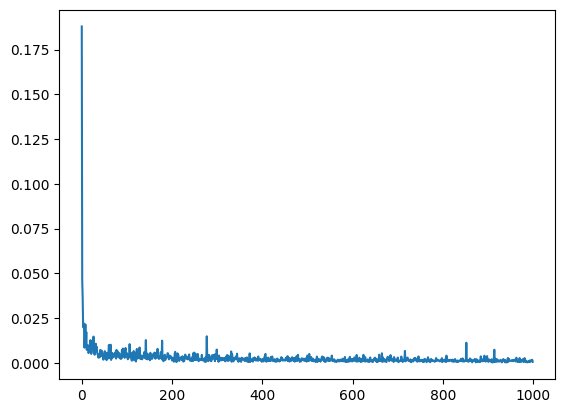

In [8]:
plt.plot(losses)

In [9]:
importlib.reload(gltensor)

# ipycanvas accepts uint8 RGB/RGBA image arrays.
# Keep both the canvas pixel buffer and the displayed widget at the image size.

rotateAngleSlider = widgets.FloatSlider(
    value=0,
    min=0.0,
    max=360.0,
    step=1,
    description="angle",
    continuous_update=True,
)

imageRender = NeRFRender(nerf, width, height)


def on_angle_change(change):
    imageRender.render_angle(change["new"])


rotateAngleSlider.observe(on_angle_change, names="value")

display(widgets.VBox([rotateAngleSlider, imageRender.canvas]))
imageRender.render_angle(rotateAngleSlider.value)